In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

In [52]:
# Grabbing files with sample data for analysis
base = Path(".")
usage_file = base / "sample_token_usage.csv"
hr_file = base / "sample_users_hr.csv"

# Business assumptions from contract data and general business cycles
contract_tokens = 1_000_000_000
contract_start = pd.Timestamp("2026-01-01")
contract_months = 12
forecast_horizon_days = 180
rolling_window_days = 28

In [53]:
usage = pd.read_csv(usage_file, parse_dates=["date"])
hr = pd.read_csv(hr_file)

# Checking out shapes and head of data to make sure they're in line with expectations
print("Usage shape:", usage.shape)
print("HR shape:", hr.shape)

display(usage.head())
display(hr.head())

# Going ahead and mapping colors for the charts for later
color_map = {
    "CC_FINANCE": "#4C78A8",
    "CC_ENGINEERING": "#F58518",
    "CC_PRODUCT": "#54A24B",
    "CC_SALES": "#E45756",
    "CC_OPERATIONS": "#72B7B2"
}

Usage shape: (18100, 3)
HR shape: (100, 6)


,date,user_email,tokens_used
0,2026-01-01,user001@example.com,20355
1,2026-01-01,user002@example.com,8752
2,2026-01-01,user003@example.com,7805
3,2026-01-01,user004@example.com,14156
4,2026-01-01,user005@example.com,16000


,user_email,cost_center,manager,title,department,location
0,user001@example.com,CC_FINANCE,alice.manager@example.com,Senior Analyst,Finance,Houston
1,user002@example.com,CC_FINANCE,alice.manager@example.com,Analyst,Finance,Houston
2,user003@example.com,CC_FINANCE,alice.manager@example.com,Analyst,Finance,Houston
3,user004@example.com,CC_FINANCE,alice.manager@example.com,Director,Finance,Houston
4,user005@example.com,CC_FINANCE,alice.manager@example.com,Manager,Finance,Houston


In [54]:
# Doing a bit of data normalizing to ensure merging the data is effective
usage["user_email"] = usage["user_email"].str.strip().str.lower()
hr["user_email"] = hr["user_email"].str.strip().str.lower()

usage["tokens_used"] = pd.to_numeric(usage["tokens_used"], errors="coerce")
usage = usage.dropna(subset=["date", "user_email", "tokens_used"])
usage = usage[usage["tokens_used"] >= 0].copy()


# Merging HR data onto usage
# HR data is unique on the email while usage has many enteries per user
df = usage.merge(hr, on="user_email", how="left")

df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()
df["week"] = df["date"].dt.to_period("W").apply(lambda r: r.start_time)

print("Merged shape:", df.shape)
display(df.head())

Merged shape: (18100, 10)


,date,user_email,tokens_used,cost_center,manager,title,department,location,month,week
0,2026-01-01,user001@example.com,20355,CC_FINANCE,alice.manager@example.com,Senior Analyst,Finance,Houston,2026-01-01,2025-12-29
1,2026-01-01,user002@example.com,8752,CC_FINANCE,alice.manager@example.com,Analyst,Finance,Houston,2026-01-01,2025-12-29
2,2026-01-01,user003@example.com,7805,CC_FINANCE,alice.manager@example.com,Analyst,Finance,Houston,2026-01-01,2025-12-29
3,2026-01-01,user004@example.com,14156,CC_FINANCE,alice.manager@example.com,Director,Finance,Houston,2026-01-01,2025-12-29
4,2026-01-01,user005@example.com,16000,CC_FINANCE,alice.manager@example.com,Manager,Finance,Houston,2026-01-01,2025-12-29


In [55]:
# Quick observation of the unique CCs, Managers, and Titles as a list
print("Cost centers:")
print(sorted(df["cost_center"].dropna().astype(str).unique().tolist()))

print("\nManagers:")
print(sorted(df["manager"].dropna().astype(str).unique().tolist())[:20])

print("\nTitles:")
print(sorted(df["title"].dropna().astype(str).unique().tolist())[:20])

Cost centers:
['CC_ENGINEERING', 'CC_FINANCE', 'CC_OPERATIONS', 'CC_PRODUCT', 'CC_SALES']

Managers:
['alice.manager@example.com', 'bob.lead@example.com', 'carol.manager@example.com', 'dave.lead@example.com', 'erin.manager@example.com', 'frank.lead@example.com', 'grace.manager@example.com', 'henry.lead@example.com', 'irene.manager@example.com', 'jack.lead@example.com']

Titles:
['Account Executive', 'Analyst', 'Director', 'Director of Operations', 'Director of Product', 'Director of Sales', 'Engineer', 'Manager', 'Operations Analyst', 'Ops Analyst', 'Ops Manager', 'Principal Engineer', 'Product Designer', 'Product Manager', 'Sales Engineer', 'Sales Ops Analyst', 'Senior Analyst', 'Senior Engineer', 'Senior Ops Analyst', 'Staff Engineer']


In [56]:
########## Analysis work starts here ##########
###############################################

# Aggregating the data by date
daily = (
    df.groupby("date", as_index=False)["tokens_used"]
      .sum()
      .sort_values("date")
)

# Analasis of cumulitive tokens used and calculating the remaining tokens on the contract, useful for burndown analysis
daily["cumulative_tokens"] = daily["tokens_used"].cumsum()
daily["remaining_tokens"] = contract_tokens - daily["cumulative_tokens"]

# Calculating the burndown and finding the ideal rate and estimated completion (simple total tokens divided by days left)
contract_end = contract_start + pd.DateOffset(months=contract_months) - pd.Timedelta(days=1)
full_dates = pd.date_range(contract_start, contract_end, freq="D")
ideal_daily_burn = contract_tokens / len(full_dates)

ideal = pd.DataFrame({"date": full_dates})
ideal["ideal_cumulative"] = np.arange(1, len(full_dates) + 1) * ideal_daily_burn
ideal["ideal_remaining"] = contract_tokens - ideal["ideal_cumulative"]



# ---------- Pretty formatting for display ----------
daily_display = daily.copy()

daily_display["tokens_used_fmt"] = daily_display["tokens_used"].map("{:,.0f}".format)
daily_display["cumulative_tokens_fmt"] = daily_display["cumulative_tokens"].map("{:,.0f}".format)
daily_display["remaining_tokens_fmt"] = daily_display["remaining_tokens"].map("{:,.0f}".format)

display(
    daily_display[[
        "date",
        "tokens_used_fmt",
        "cumulative_tokens_fmt",
        "remaining_tokens_fmt"
    ]].head()
)


,date,tokens_used_fmt,cumulative_tokens_fmt,remaining_tokens_fmt
0,2026-01-01,"3,108,946","3,108,946","996,891,054"
1,2026-01-02,"3,106,761","6,215,707","993,784,293"
2,2026-01-03,"2,958,543","9,174,250","990,825,750"
3,2026-01-04,"1,638,303","10,812,553","989,187,447"
4,2026-01-05,"1,209,047","12,021,600","987,978,400"


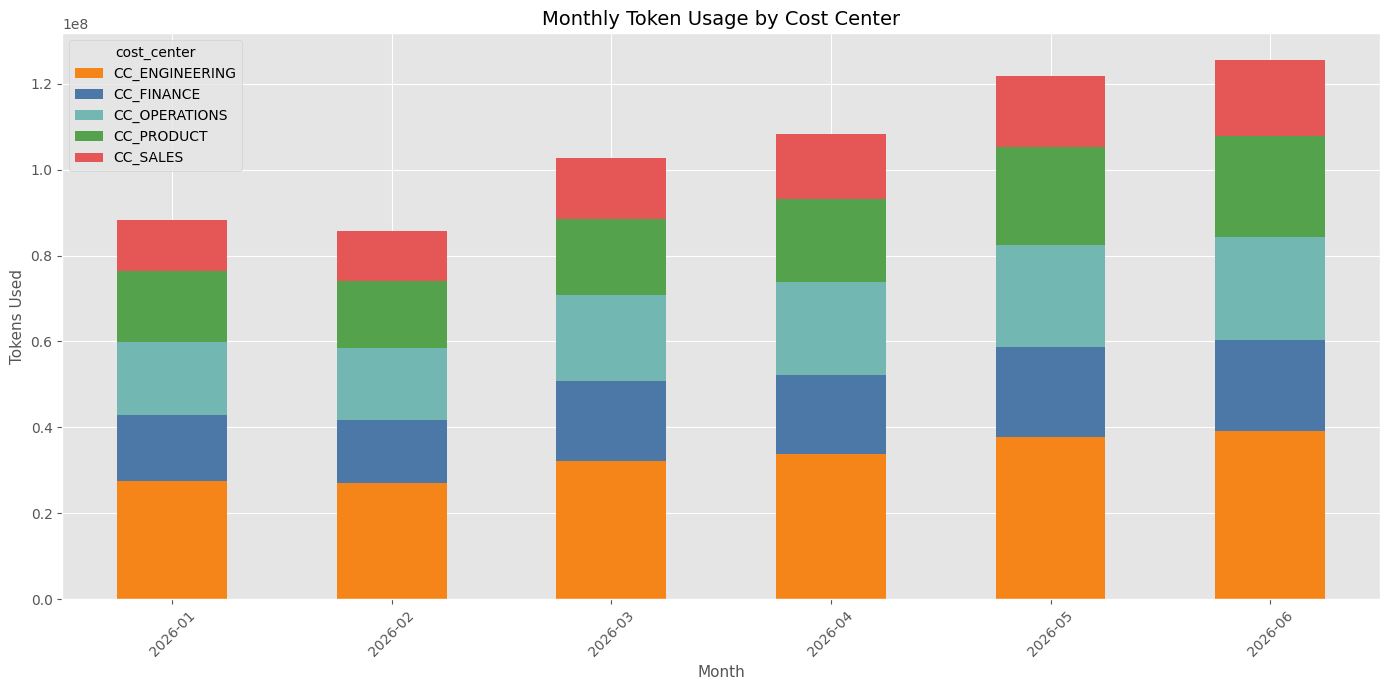

In [57]:
# Aggregate monthly usage by cost center
monthly_cc = (
    df.groupby(["month", "cost_center"], as_index=False)["tokens_used"]
      .sum()
      .sort_values(["month", "cost_center"])
)

# Pivot to wide format for plotting
monthly_cc_pivot = (
    monthly_cc
    .pivot(index="month", columns="cost_center", values="tokens_used")
    .fillna(0)
)

# Make x-axis labels nicer
monthly_cc_pivot.index = monthly_cc_pivot.index.to_period("M").astype(str)

##### Defined towards the top under "color_map" 
plot_colors = [color_map.get(cc, "#B0B0B0") for cc in monthly_cc_pivot.columns]

# Plot stacked bar
ax = monthly_cc_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    color=plot_colors
)

ax.set_title("Monthly Token Usage by Cost Center")
ax.set_xlabel("Month")
ax.set_ylabel("Tokens Used")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

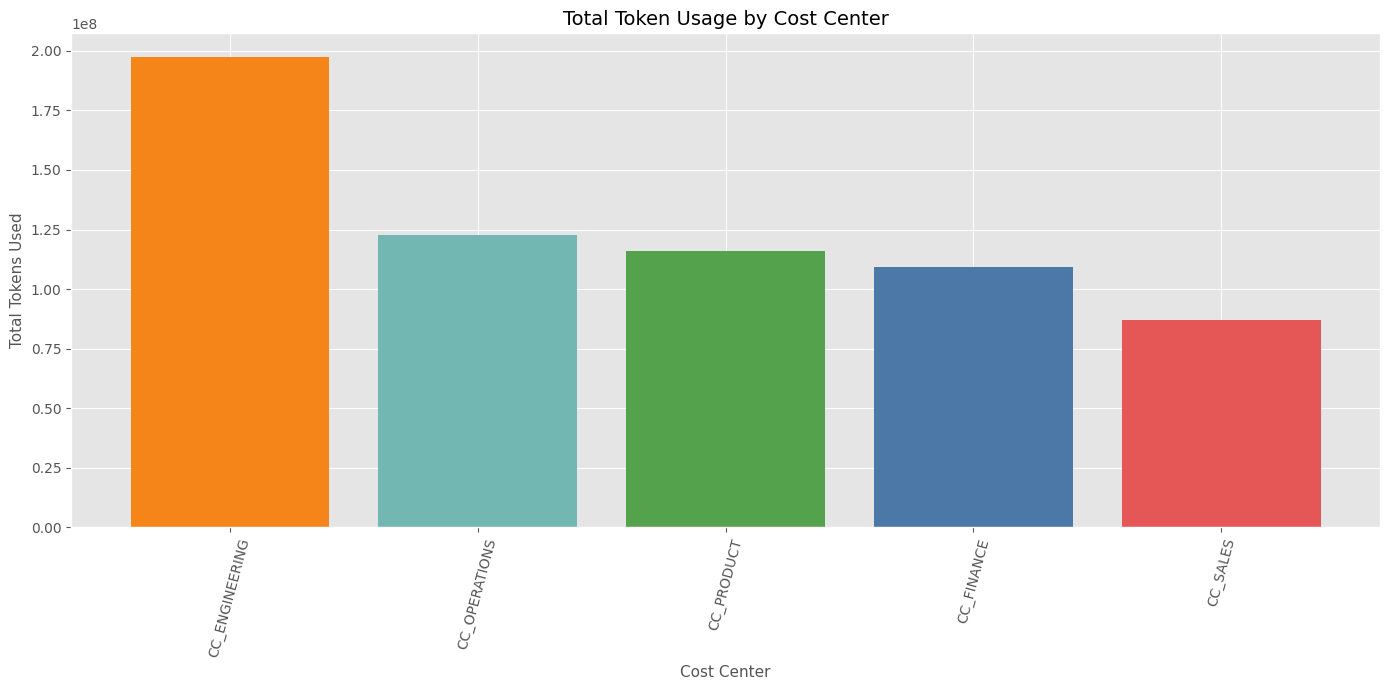

,cost_center,total_tokens_used_fmt,unique_users,pct_all_tokens_fmt,tokens_per_capita_fmt
0,CC_ENGINEERING,"197,497,713",31,31.24%,"6,370,893.97"
2,CC_OPERATIONS,"122,777,580",20,19.42%,"6,138,879.00"
3,CC_PRODUCT,"115,840,912",18,18.32%,"6,435,606.22"
1,CC_FINANCE,"109,197,494",19,17.27%,"5,747,236.53"
4,CC_SALES,"86,965,081",12,13.75%,"7,247,090.08"


In [58]:
# --- Cost center totals with percent of total ---
# --- Bar colors represent cost center ---

# Gives the grand total token usage, which will be used to compute each cost center’s share.
total_tokens_all = df["tokens_used"].sum()

# Grouping data by cost center and calculating basic metrics
cost_center_summary = (
    df.groupby("cost_center", as_index=False)
      .agg(
          total_tokens_used=("tokens_used", "sum"),
          unique_users=("user_email", "nunique")
      )
      .assign(
          pct_all_tokens=lambda x: x["total_tokens_used"] / total_tokens_all,
          tokens_per_capita=lambda x: x["total_tokens_used"] / x["unique_users"]
      )
      .sort_values("total_tokens_used", ascending=False)
      .copy()
)

cost_center_summary["pct_all_tokens"] = cost_center_summary["pct_all_tokens"].round(4)
cost_center_summary["tokens_per_capita"] = cost_center_summary["tokens_per_capita"].round(2)


# Grabbing the predefined cost center color mapping from the top
cost_center_summary["bar_color"] = (
    cost_center_summary["cost_center"].map(color_map).fillna("#B0B0B0")
)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(
    cost_center_summary["cost_center"],
    cost_center_summary["total_tokens_used"],
    color=cost_center_summary["bar_color"]
)

ax.set_title("Total Token Usage by Cost Center")
ax.set_xlabel("Cost Center")
ax.set_ylabel("Total Tokens Used")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

# ---------- Pretty formatting for display ----------
cost_center_summary["total_tokens_used_fmt"] = (
    cost_center_summary["total_tokens_used"].map("{:,.0f}".format)
)
cost_center_summary["tokens_per_capita_fmt"] = (
    cost_center_summary["tokens_per_capita"].map("{:,.2f}".format)
)
cost_center_summary["pct_all_tokens_fmt"] = (
    (cost_center_summary["pct_all_tokens"] * 100).map("{:.2f}%".format)
)

display(
    cost_center_summary[
        [
            "cost_center",
            "total_tokens_used_fmt",
            "unique_users",
            "pct_all_tokens_fmt",
            "tokens_per_capita_fmt"
        ]
    ]
)


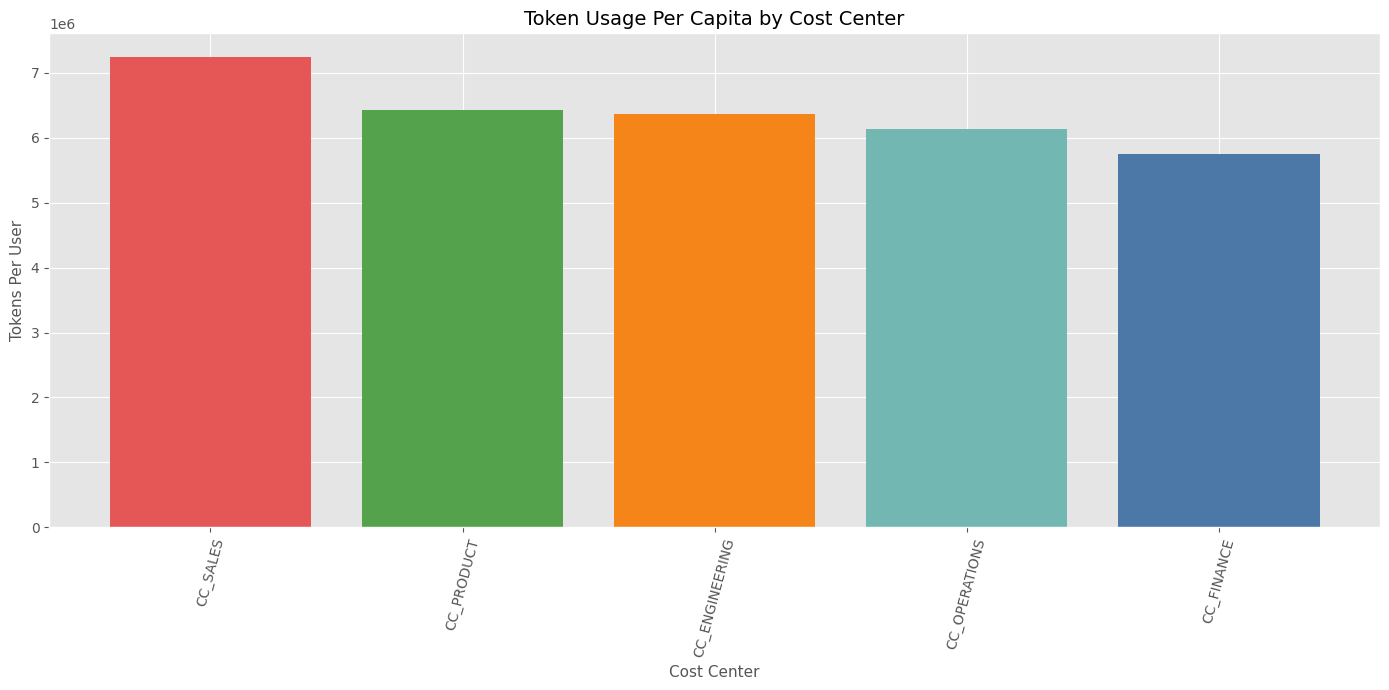

,cost_center,total_tokens_used_fmt,unique_users,pct_all_tokens_fmt,tokens_per_capita_fmt
4,CC_SALES,"86,965,081",12,13.75%,"7,247,090.08"
3,CC_PRODUCT,"115,840,912",18,18.32%,"6,435,606.22"
0,CC_ENGINEERING,"197,497,713",31,31.24%,"6,370,893.97"
2,CC_OPERATIONS,"122,777,580",20,19.42%,"6,138,879.00"
1,CC_FINANCE,"109,197,494",19,17.27%,"5,747,236.53"


In [59]:
# --- Cost center usage per capita ---

per_capita = cost_center_summary.sort_values("tokens_per_capita", ascending=False).copy()

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(
    per_capita["cost_center"],
    per_capita["tokens_per_capita"],
    color=per_capita["bar_color"]
)

ax.set_title("Token Usage Per Capita by Cost Center")
ax.set_xlabel("Cost Center")
ax.set_ylabel("Tokens Per User")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()


# ---------- Pretty formatting for display ----------
per_capita["total_tokens_used_fmt"] = per_capita["total_tokens_used"].map("{:,.0f}".format)
per_capita["tokens_per_capita_fmt"] = per_capita["tokens_per_capita"].map("{:,.2f}".format)
per_capita["pct_all_tokens_fmt"] = (per_capita["pct_all_tokens"] * 100).map("{:.2f}%".format)

display(
    per_capita[
        [
            "cost_center",
            "total_tokens_used_fmt",
            "unique_users",
            "pct_all_tokens_fmt",
            "tokens_per_capita_fmt"
        ]
    ]
)


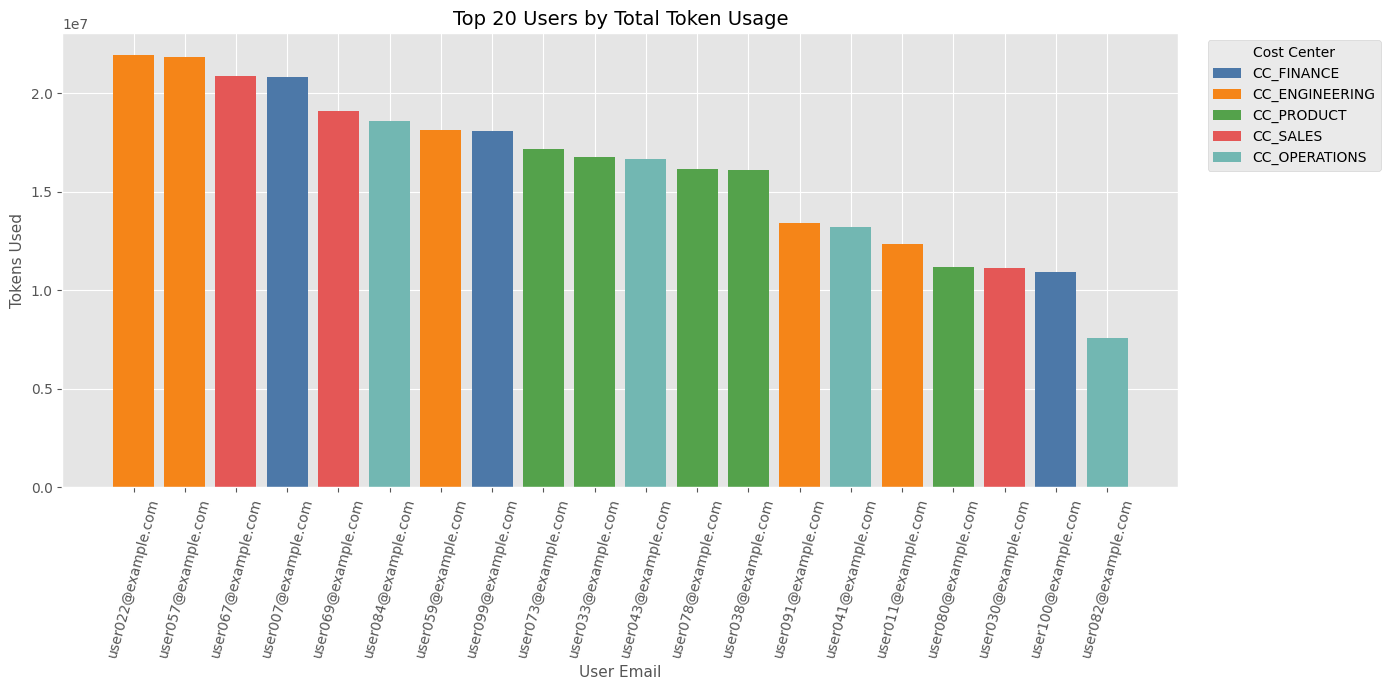

,user_email,cost_center,manager,title,tokens_used_fmt,pct_all_tokens_fmt,pct_cost_center_tokens_fmt
21,user022@example.com,CC_ENGINEERING,erin.manager@example.com,Sales Engineer,"21,948,046",3.47%,11.11%
56,user057@example.com,CC_ENGINEERING,dave.lead@example.com,Engineer,"21,866,269",3.46%,11.07%
66,user067@example.com,CC_SALES,frank.lead@example.com,Sales Engineer,"20,872,179",3.30%,24.00%
6,user007@example.com,CC_FINANCE,bob.lead@example.com,Analyst,"20,806,078",3.29%,19.05%
68,user069@example.com,CC_SALES,frank.lead@example.com,Account Executive,"19,085,097",3.02%,21.95%
83,user084@example.com,CC_OPERATIONS,jack.lead@example.com,Ops Manager,"18,582,666",2.94%,15.14%
58,user059@example.com,CC_ENGINEERING,dave.lead@example.com,Engineer,"18,158,600",2.87%,9.19%
98,user099@example.com,CC_FINANCE,bob.lead@example.com,Analyst,"18,090,251",2.86%,16.57%
72,user073@example.com,CC_PRODUCT,henry.lead@example.com,Product Manager,"17,155,656",2.71%,14.81%
32,user033@example.com,CC_PRODUCT,grace.manager@example.com,Product Designer,"16,786,740",2.65%,14.49%


In [60]:
# --- Top users with percent of total and percent within cost center ---
# --- Bar colors represent cost center ---

from matplotlib.patches import Patch

total_tokens_all = df["tokens_used"].sum()

cost_center_totals = (
    df.groupby("cost_center", as_index=False)["tokens_used"]
      .sum()
      .rename(columns={"tokens_used": "cost_center_total_tokens"})
)

top_users = (
    df.groupby(["user_email", "cost_center", "manager", "title"], as_index=False)["tokens_used"]
      .sum()
      .merge(cost_center_totals, on="cost_center", how="left")
      .assign(
          pct_all_tokens=lambda x: x["tokens_used"] / total_tokens_all,
          pct_cost_center_tokens=lambda x: x["tokens_used"] / x["cost_center_total_tokens"]
      )
      .sort_values("tokens_used", ascending=False)
      .head(20)
      .copy()
)

top_users["pct_all_tokens"] = top_users["pct_all_tokens"].round(4)
top_users["pct_cost_center_tokens"] = top_users["pct_cost_center_tokens"].round(4)


##### Defined towards the top under "color_map"
top_users["bar_color"] = top_users["cost_center"].map(color_map).fillna("#B0B0B0")

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(
    top_users["user_email"],
    top_users["tokens_used"],
    color=top_users["bar_color"]
)

ax.set_title("Top 20 Users by Total Token Usage")
ax.set_xlabel("User Email")
ax.set_ylabel("Tokens Used")
plt.xticks(rotation=75)

legend_handles = [
    Patch(facecolor=color, label=cc)
    for cc, color in color_map.items()
    if cc in top_users["cost_center"].unique()
]
ax.legend(handles=legend_handles, title="Cost Center", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()




# ---------- Pretty formatting for display ----------
top_users["tokens_used_fmt"] = top_users["tokens_used"].map("{:,.0f}".format)
top_users["pct_all_tokens_fmt"] = (top_users["pct_all_tokens"] * 100).map("{:.2f}%".format)
top_users["pct_cost_center_tokens_fmt"] = (top_users["pct_cost_center_tokens"] * 100).map("{:.2f}%".format)

display(
    top_users[
        [
            "user_email",
            "cost_center",
            "manager",
            "title",
            "tokens_used_fmt",
            "pct_all_tokens_fmt",
            "pct_cost_center_tokens_fmt"
        ]
    ]
)


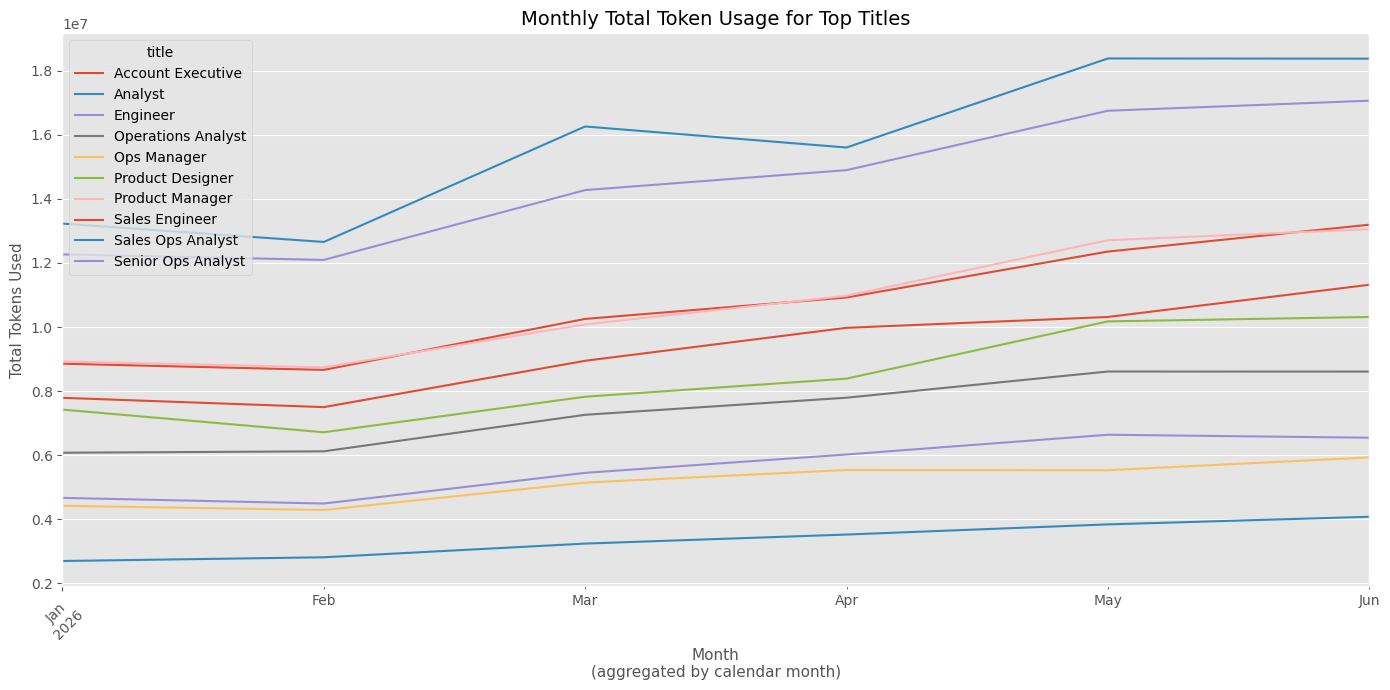

In [61]:
# --- Monthly total token usage by title (not per capita) ---

# Aggregate total monthly tokens by (month, title)
#    This gives you the total tokens used in that month for each month and job title.
monthly_title = (
    df.groupby(["month", "title"], as_index=False)["tokens_used"]
      .sum()
)

# Find the top 10 titles by overall token usage across the entire dataset
#    This ensures the chart focuses on the biggest consumers rather than every possible title.
top_titles = (
    df.groupby("title", as_index=False)["tokens_used"]
      .sum()
      .sort_values("tokens_used", ascending=False)
      .head(10)["title"]
      .tolist()
)

# Filter the monthly data down to only those top titles
#    This keeps the time‑series plot readable and focused.
monthly_title_top = monthly_title[monthly_title["title"].isin(top_titles)].copy()

# Pivot to wide format: one row per month, one column per title, values = total tokens
#    This format makes it easy to plot multiple title lines across time.
pivot_title = (
    monthly_title_top
    .pivot(index="month", columns="title", values="tokens_used")
    .fillna(0)  # months with no usage for a title become 0 instead of NaN
)

# Plot the monthly total token usage for the top titles
ax = pivot_title.plot(figsize=(14, 7))

# Add chart text and formatting
ax.set_title("Monthly Total Token Usage for Top Titles")
ax.set_xlabel("Month\n(aggregated by calendar month)")
ax.set_ylabel("Total Tokens Used")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

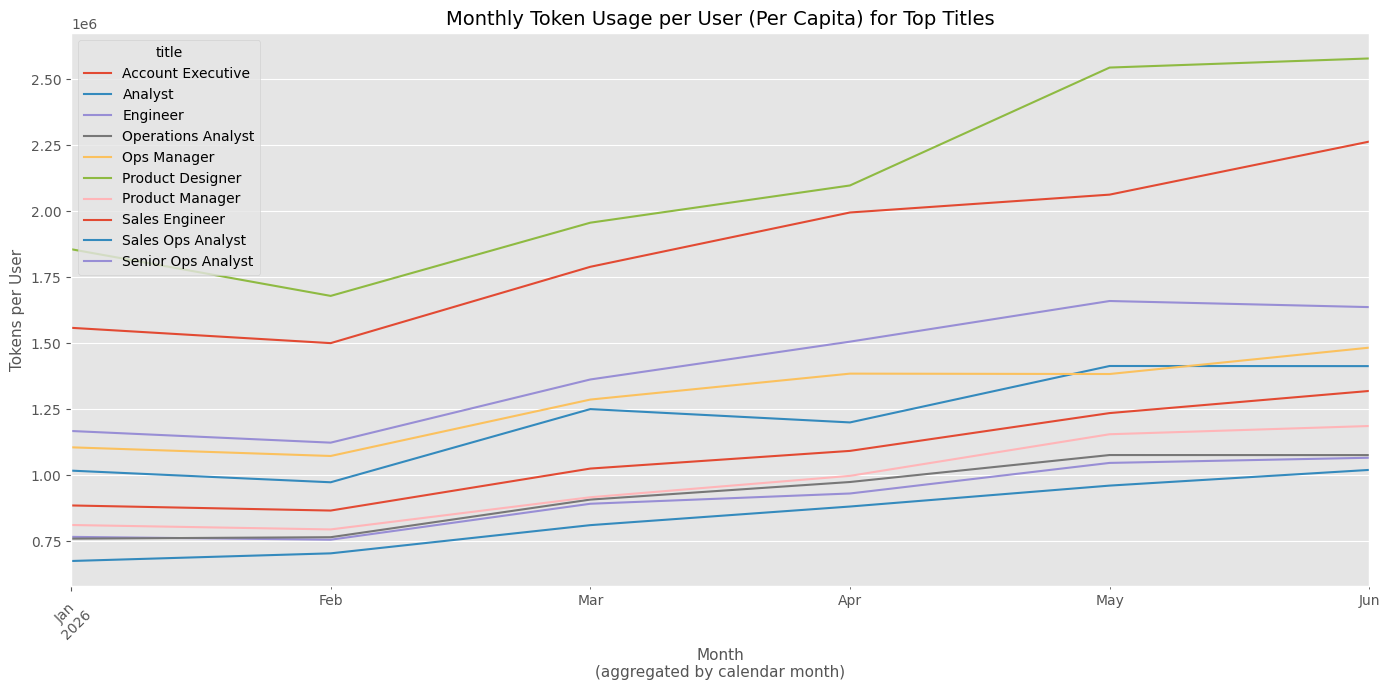

In [62]:
# --- Monthly per-capita token usage by title ---

# Aggregate monthly tokens and unique users per (month, title)
monthly_title = (
    df.groupby(["month", "title"], as_index=False)
      .agg(
          tokens_used=("tokens_used", "sum"),
          unique_users=("user_email", "nunique")
      )
)

# Compute per-capita usage: tokens per unique user in that month & title
monthly_title["tokens_per_capita"] = (
    monthly_title["tokens_used"] / monthly_title["unique_users"]
)

# Find top titles by total tokens (you could also rank by per-capita if desired)
top_titles = (
    df.groupby("title", as_index=False)["tokens_used"]
      .sum()
      .sort_values("tokens_used", ascending=False)
      .head(10)["title"]
      .tolist()
)

# Keep only those top titles
monthly_title_top = monthly_title[monthly_title["title"].isin(top_titles)].copy()

# Pivot to wide format using per-capita values
pivot_title = (
    monthly_title_top
    .pivot(index="month", columns="title", values="tokens_per_capita")
    .fillna(0)
)

# Plot
ax = pivot_title.plot(figsize=(14, 7))


ax.set_title("Monthly Token Usage per User (Per Capita) for Top Titles")
ax.set_xlabel("Month\n(aggregated by calendar month)")
ax.set_ylabel("Tokens per User")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
# --- User-level concentration metrics ---


# Aggregate total token usage per user and sort by heaviest users
user_totals = (
    df.groupby("user_email", as_index=False)["tokens_used"]
      .sum()                               # total tokens per user across the period
      .sort_values("tokens_used", ascending=False)  # largest users at the top
)

# Compute overall total usage across all users
total_usage = user_totals["tokens_used"].sum()

# Compute share of total usage for top 10 and top 20 users
top_10_share = user_totals.head(10)["tokens_used"].sum() / total_usage
top_20_share = user_totals.head(20)["tokens_used"].sum() / total_usage

# Build a small summary table of concentration metrics
#    This is an easy-to-read view for stakeholders.
concentration = pd.DataFrame({
    "metric": ["top_10_user_share", "top_20_user_share", "total_usage"],
    "value": [top_10_share, top_20_share, total_usage]
})


# ---------- Pretty formatting for display ----------
concentration["value_fmt"] = concentration.apply(
    lambda row: (
        f"{row['value'] * 100:.2f}%" 
        if row["metric"] in ["top_10_user_share", "top_20_user_share"]
        else f"{row['value']:,.0f}"
    ),
    axis=1
)

# Display a compact table for quick interpretation
display(concentration[["metric", "value_fmt"]])

,metric,value_fmt
0,top_10_user_share,30.58%
1,top_20_user_share,50.94%
2,total_usage,"632,278,780"


In [64]:
# --- Recent trend and weekday profile analysis ---

# Rolling average of daily usage
#    This adds a smoothed view of daily usage over the last `rolling_window_days` days.
#    It helps reduce noise and highlight the underlying trend.
daily["rolling_avg"] = daily["tokens_used"].rolling(rolling_window_days).mean()

# Recent average daily burn over the most recent `rolling_window_days`
#    This is the baseline "current" usage level used for forecasting.
recent_burn = daily["tokens_used"].tail(rolling_window_days).mean()

# Look at the last 56 days to estimate growth in usage
#    We split the last 56 days into two halves (first 28 days vs last 28 days)
#    to see if usage is increasing.
recent_56 = daily["tokens_used"].tail(56).reset_index(drop=True)
first_half = recent_56.iloc[:28].mean()    # average daily usage in days -56 to -29
second_half = recent_56.iloc[28:].mean()   # average daily usage in days -28 to -1

# Estimate a simple daily growth rate based on those two halves
#    - If second_half > first_half, this implies growth.
#    - (second_half / first_half) - 1 gives the total growth over 28 days.
#    - Divide by 28 to approximate an average daily growth rate.
#    - max(..., 0) prevents negative growth (we clamp it at 0, i.e., no shrink).
#    - If first_half is 0 (no usage), avoid division by zero and set growth to 0.
daily_growth_rate = max((second_half / first_half) - 1, 0) / 28 if first_half > 0 else 0

# Build a weekday usage profile (0 = Monday, ..., 6 = Sunday)
#    This captures systematic differences, e.g., weekdays heavier than weekends.
weekday_profile = (
    df.assign(weekday=df["date"].dt.weekday)    # add a weekday column based on the date
      .groupby("weekday", as_index=False)["tokens_used"]
      .mean()                                   # average tokens used on each weekday
)

# Turn weekday averages into a dictionary and compute the overall mean
#    weekday_map[weekday] = typical tokens_used on that weekday.
#    weekday_mean is the average of those weekday averages.
weekday_map = dict(zip(weekday_profile["weekday"], weekday_profile["tokens_used"]))
weekday_mean = np.mean(list(weekday_map.values()))

# Print a concise summary of current usage and growth
#    - recent_burn formatted with commas and 2 decimals.
#    - daily_growth_rate converted to a percentage.
print("Recent avg daily burn:", f"{recent_burn:,.2f}")
print("Implied daily growth rate:", f"{daily_growth_rate * 100:.2f}%")

# Add a formatted column for weekday averages (for nicer display)
weekday_profile["tokens_used_fmt"] = weekday_profile["tokens_used"].map("{:,.2f}".format)

# Display weekday profile with readable numbers
display(
    weekday_profile[["weekday", "tokens_used_fmt"]]
)

Recent avg daily burn: 4,214,694.21
Implied daily growth rate: 0.18%


,weekday,tokens_used_fmt
0,0,"18,619.82"
1,1,"43,248.38"
2,2,"45,795.26"
3,3,"40,121.89"
4,4,"39,017.08"
5,5,"36,502.93"
6,6,"21,640.15"


In [65]:
# --- Forecast future usage and projected runout ---

# Find the last date with actual usage data
#    This is the "starting point" for the forecast; all future dates are relative to this.
last_date = daily["date"].max()

# Build a list of forecasted daily usage rows for the chosen horizon
forecast_rows = []
for i in range(1, forecast_horizon_days + 1):
    # Compute the forecast date: i days after the last actual date
    f_date = last_date + pd.Timedelta(days=i)
    
    # Get the weekday adjustment factor for this date
    #     - weekday_map[f_date.weekday()] is the typical tokens_used for that weekday.
    #     - If not found, fall back to the overall weekday_mean.
    weekday_adj = weekday_map.get(f_date.weekday(), weekday_mean)
    
    # Forecast tokens used on that day
    #     Formula pieces:
    #       - recent_burn: baseline recent average daily usage
    #       - (1 + daily_growth_rate) ** i: compound growth i days into the future
    #       - (weekday_adj / weekday_mean): scale up/down based on typical usage for that weekday compared to an average day.
    pred = recent_burn * ((1 + daily_growth_rate) ** i) * (weekday_adj / weekday_mean)

    # Store this day's forecast in a list (to turn into a DataFrame later)
    forecast_rows.append({
        "date": f_date,
        "forecast_tokens_used": pred
    })

# Convert the list of forecast rows into a DataFrame
forecast = pd.DataFrame(forecast_rows)

# Compute future cumulative forecast usage
#    This is the running sum of predicted daily usage from tomorrow onward.
forecast["forecast_cumulative_future"] = forecast["forecast_tokens_used"].cumsum()

# Add future usage to the historical cumulative usage
#    - daily["cumulative_tokens"].iloc[-1] is the total tokens used up to last_date.
#    - Adding the forecast cumulative gives projected total used at each future date.
forecast["projected_cumulative_total"] = (
    daily["cumulative_tokens"].iloc[-1] + forecast["forecast_cumulative_future"]
)

# Compute projected remaining tokens at each future date
#    Subtract projected total used from the contract token cap.
forecast["projected_remaining"] = contract_tokens - forecast["projected_cumulative_total"]

# Find the first date where remaining tokens go to zero or below
#    This is the projected contract runout date under the current forecast.
runout = forecast.loc[forecast["projected_remaining"] <= 0, "date"]
projected_runout_date = runout.iloc[0] if len(runout) else pd.NaT

print("Projected runout date:", projected_runout_date)

# -------- Pretty formatting for display  --------
forecast_display = forecast.copy()

forecast_display["forecast_tokens_used_fmt"] = forecast_display["forecast_tokens_used"].map("{:,.0f}".format)
forecast_display["forecast_cumulative_future_fmt"] = forecast_display["forecast_cumulative_future"].map("{:,.0f}".format)
forecast_display["projected_cumulative_total_fmt"] = forecast_display["projected_cumulative_total"].map("{:,.0f}".format)
forecast_display["projected_remaining_fmt"] = forecast_display["projected_remaining"].map("{:,.0f}".format)

display(
    forecast_display[
        [
            "date",
            "forecast_tokens_used_fmt",
            "forecast_cumulative_future_fmt",
            "projected_cumulative_total_fmt",
            "projected_remaining_fmt"
        ]
    ].head()
)

Projected runout date: 2026-09-19 00:00:00


,date,forecast_tokens_used_fmt,forecast_cumulative_future_fmt,projected_cumulative_total_fmt,projected_remaining_fmt
0,2026-07-01,"5,526,056","5,526,056","637,804,836","362,195,164"
1,2026-07-02,"4,850,384","10,376,440","642,655,220","357,344,780"
2,2026-07-03,"4,725,521","15,101,961","647,380,741","352,619,259"
3,2026-07-04,"4,429,174","19,531,135","651,809,915","348,190,085"
4,2026-07-05,"2,630,603","22,161,738","654,440,518","345,559,482"


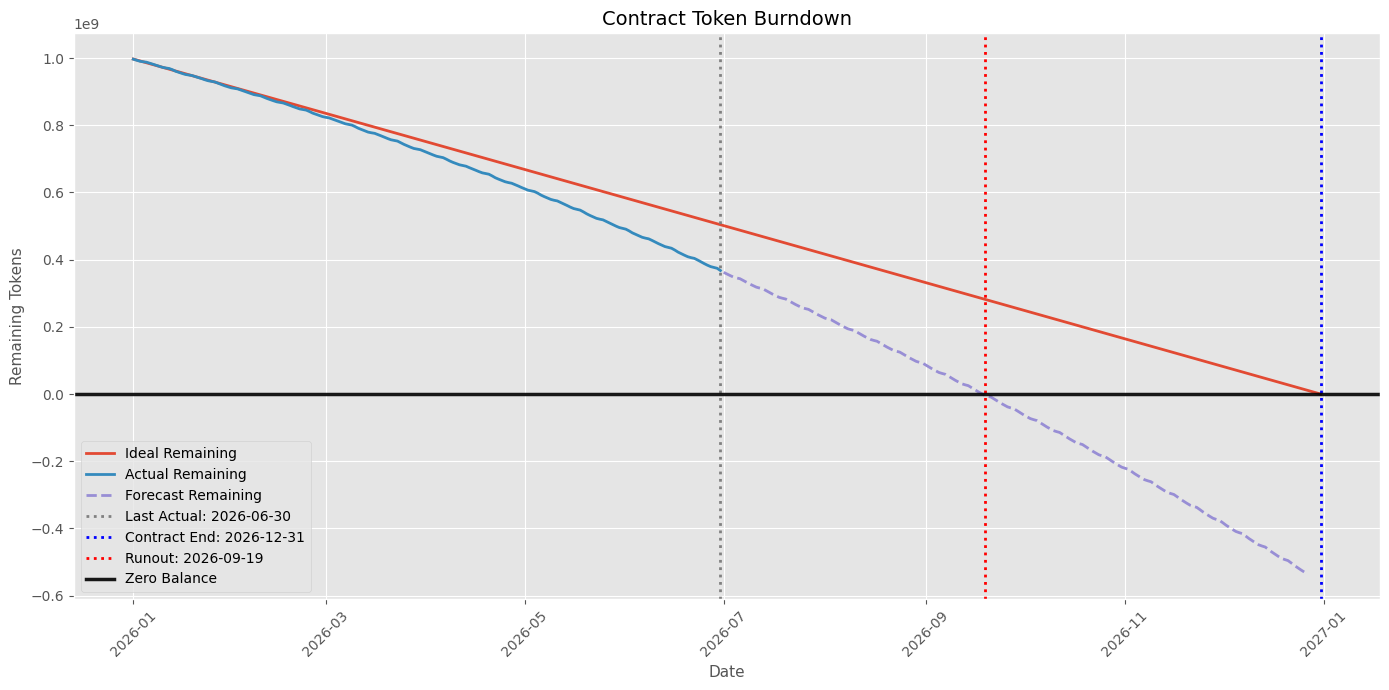

In [66]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(ideal["date"], ideal["ideal_remaining"], label="Ideal Remaining", linewidth=2)
ax.plot(daily["date"], daily["remaining_tokens"], label="Actual Remaining", linewidth=2)
ax.plot(forecast["date"], forecast["projected_remaining"], label="Forecast Remaining", linestyle="--", linewidth=2)

# Last real usage date
ax.axvline(
    last_date,
    color="gray",
    linestyle=":",
    linewidth=2,
    label=f"Last Actual: {last_date.date()}"
)

# Contract end date
ax.axvline(
    contract_end,
    color="blue",
    linestyle=":",
    linewidth=2,
    label=f"Contract End: {contract_end.date()}"
)

# Runout date (if any)
if pd.notna(projected_runout_date):
    ax.axvline(
        projected_runout_date,
        color="red",
        linestyle=":",
        linewidth=2,
        label=f"Runout: {projected_runout_date.date()}"
    )

# More prominent zero line
ax.axhline(
    y=0,
    color="black",
    linewidth=2.5,
    linestyle="-",
    alpha=0.9,
    label="Zero Balance"
)

ax.set_title("Contract Token Burndown")
ax.set_xlabel("Date")
ax.set_ylabel("Remaining Tokens")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
daily.to_csv("daily_burndown.csv", index=False)
forecast.to_csv("forecast_burndown.csv", index=False)
monthly_cc.to_csv("monthly_cost_center_usage.csv", index=False)
top_users.to_csv("top_users_usage.csv", index=False)


print("Exported analysis CSVs.")